# Customer Churn Prediction Model Project
## Introduction
Customer churn is a critical challenge for businesses, especially in highly competitive industries such as the service industry, like telecommunications. The cost of acquiring a new customer is up to six times higher than retaining an existing customer.

In this project, we aim to build a predictive model that identifies customers who are at high risk of churning based on historical data. By identifying these customers, businesses can take proactive measures to improve retention and increase profitability. 

## Objective
The primary goal is to develop a binary classification model that predicts whether a customer will leave the service (churn = Yes) or stay (churn = No) based on their demographic information, account details, and usage patterns.

## Dataset
This project uses the **Telco Customer Churn dataset** from Kaggle.
The dataset contains information about:
- Customer demographics (gender, senior citizen status, etc.)  
- Account information (tenure, contract type, payment method)  
- Services subscribed (internet, phone, streaming, etc.)  
- Billing details (monthly charges, total charges)  
- Churn status (whether the customer left or stayed)

## Project Workflow
The project will follow these steps:
1. Data Loading  
2. Data Exploration (EDA)  
3. Data Cleaning & Preprocessing  
4. Feature Engineering  
5. Model Building  
6. Model Evaluation  
7. Insights & Conclusion  

## Business Impact
Predicting customer churn helps companies:
- Reduce customer loss  
- Improve customer satisfaction  
- Increase revenue through retention strategies  
- Make data-driven decisions

## Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing & Machine Learning Models
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

## Loading the Dataset

In [2]:
customer_churn_dataset = pd.read_csv('Telco-Customer-Churn.csv')

# preview the first five rows
customer_churn_dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploring the Dataset

In [3]:
# The shape of the dataset
customer_churn_dataset.shape

(7043, 21)

In [4]:
# Column name
customer_churn_dataset.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
# Data types and missing values
customer_churn_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Statistical summary
customer_churn_dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# Check target variable distribution
customer_churn_dataset['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## Data Cleaning

In [8]:
# Let's check the TotalCharges unique value
customer_churn_dataset["TotalCharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [9]:
# To fix the error we will need to convert the TotalCharges to numeric the remove the "..."
customer_churn_dataset["TotalCharges"] = pd.to_numeric(customer_churn_dataset["TotalCharges"], errors="coerce")

In [10]:
# let's check how many null value are there
TotalCharges_null = customer_churn_dataset["TotalCharges"].isnull().sum()
print(TotalCharges_null)

11


In [11]:
# Since it's only 11 rows out of 7043, it's safe to drop them
customer_churn_dataset = customer_churn_dataset.dropna()

In [12]:
# CustomerID is not useful for prediction. We can remove it.
customer_churn_dataset = customer_churn_dataset.drop('customerID', axis=1)

In [13]:
#Quick check of data types
print("\nColumn Data Types:")
print(customer_churn_dataset.dtypes.value_counts())


Column Data Types:
object     16
int64       2
float64     2
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

### Visualize the Target Variable Distribution

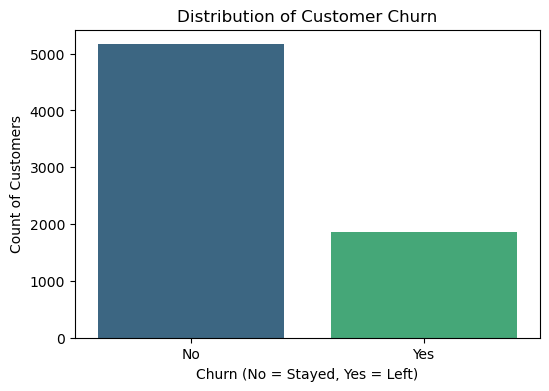

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=customer_churn_dataset, palette='viridis')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn (No = Stayed, Yes = Left)')
plt.ylabel('Count of Customers')
plt.savefig('images/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Analyzing Churn by Contract Type

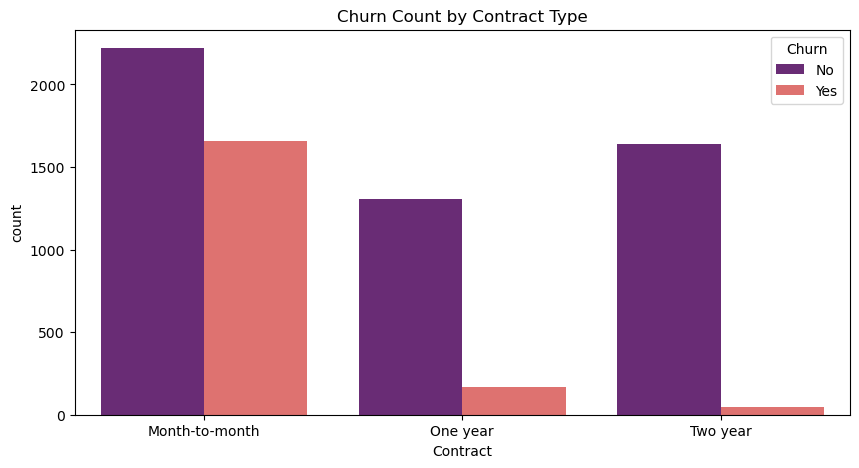

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=customer_churn_dataset, palette='magma')
plt.title('Churn Count by Contract Type')
plt.savefig('images/contract_churn.png', dpi=300, bbox_inches='tight')
plt.show()
plt.tight_layout()

### Monthly Charges vs Churn

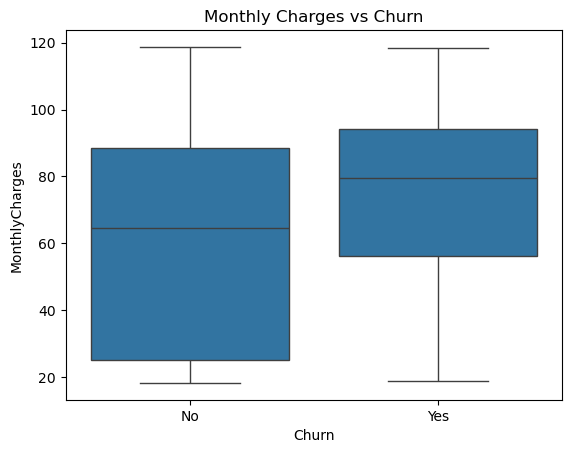

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=customer_churn_dataset)
plt.title('Monthly Charges vs Churn')
plt.savefig('images/tenure_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Tenure vs Churn

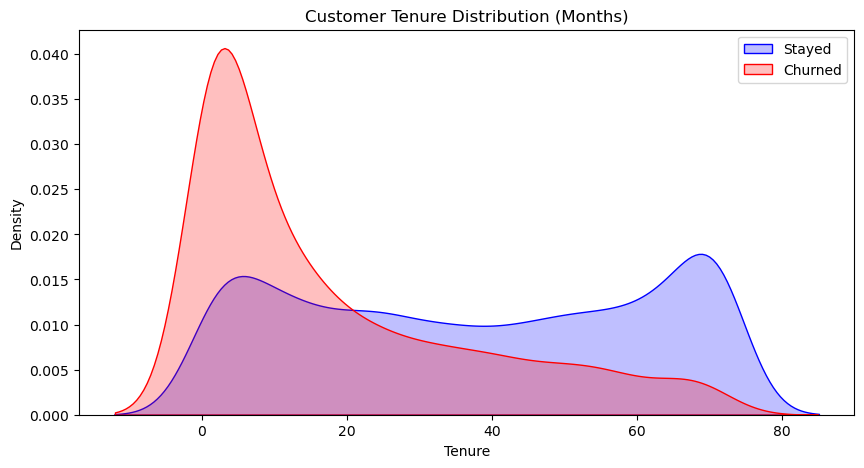

In [ ]:
plt.figure(figsize=(10, 5))
sns.kdeplot(customer_churn_dataset[customer_churn_dataset['Churn'] == 'No']['tenure'], fill=True, color="blue", label="Stayed")
sns.kdeplot(customer_churn_dataset[customer_churn_dataset['Churn'] == 'Yes']['tenure'], fill=True, color="red", label="Churned")
plt.title('Customer Tenure Distribution (Months)')
plt.xlabel('Tenure')
plt.legend()
plt.savefig('images/tenure_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Feature Engineering

In [18]:
# Label Encoding: For binary columns (e.g., Yes/No) 
# Such as gender, partner, Dependents, PhoneService, OnlineSecurity, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, PaperlessBilling.

binary_cols = [col for col in customer_churn_dataset.columns if customer_churn_dataset[col].nunique() == 2]

In [19]:
le = LabelEncoder()
for col in binary_cols:
     customer_churn_dataset[col] = le.fit_transform(customer_churn_dataset[col])

In [20]:
customer_churn_dataset.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [21]:
# Multi-category columns (more than 2 unique values)
multi_cols =[col for col in customer_churn_dataset.columns if customer_churn_dataset[col].nunique() > 2 and customer_churn_dataset[col].dtype =='object']

# One-Hot Encoding for Multi-category columns
customer_churn_dataset = pd.get_dummies(customer_churn_dataset, columns=multi_cols, drop_first=True)

In [22]:
customer_churn_dataset.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


## Feature Selection and Data Splitting

In [23]:
X = customer_churn_dataset.drop('Churn', axis=1) # features
y = customer_churn_dataset['Churn'] # target

In [24]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Handling Class Imbalance (SMOTE)

In [26]:
smote = SMOTE(random_state=42)

In [27]:

# Apply SMOTE to scaled Logistic Regression
X_train_resampled_scaled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"Original training shape: {y_train.value_counts()}")
print("Balance Data with SMOTE:", pd.Series(y_train_resampled).value_counts())

Original training shape: Churn
0    4130
1    1495
Name: count, dtype: int64
Balance Data with SMOTE: Churn
1    4130
0    4130
Name: count, dtype: int64


### Model Building and Training

In [28]:
# LogisticRegression
logist_reg = LogisticRegression(max_iter=1000, random_state=42)
logist_reg.fit(X_train_resampled_scaled, y_train_resampled)
logist_reg_predict = logist_reg.predict(X_test_scaled)

### HYPERPARAMETER TUNING (Random Forest)

In [29]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
# Scoring for 'recall' because we want to catch churners!
random_forest = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='recall', n_jobs=-1)
random_forest.fit(X_train_resampled_scaled, y_train_resampled)
best_rf = random_forest.best_estimator_
random_forest_predict = random_forest.predict(X_test_scaled)
print(f"Best RF Parameters: {random_forest.best_params_}")

Best RF Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


### Model Evaluation

--- Logistic Regression Performance ---
Accuracy: 0.7356

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



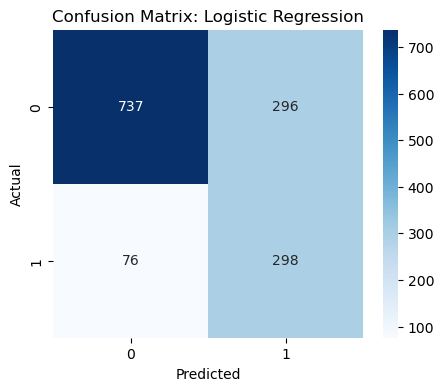



--- Random Forest Performance ---
Accuracy: 0.7584

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1033
           1       0.53      0.71      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407



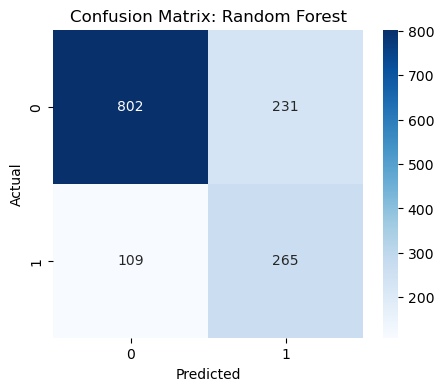

In [ ]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Plotting the Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f'images/confusion_matrix_{model_name.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n" + "="*40 + "\n")

evaluate_model(y_test, logist_reg_predict, "Logistic Regression")
evaluate_model(y_test, random_forest_predict, "Random Forest")

### ROC CURVE

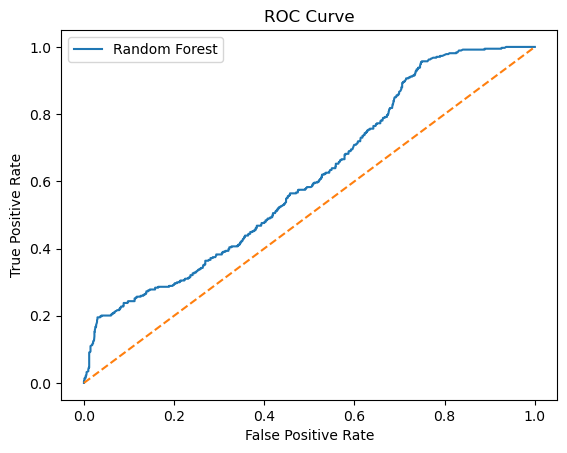

ROC-AUC Score: 0.6091636425757488


In [ ]:
y_probs = best_rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig('images/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_probs))

### CROSS VALIDATION

In [32]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

scores = cross_val_score(pipeline, X, y, cv=5)
print("Cross-validation score:", scores.mean())

Cross-validation score: 0.8030420949509715


### Feature Importance

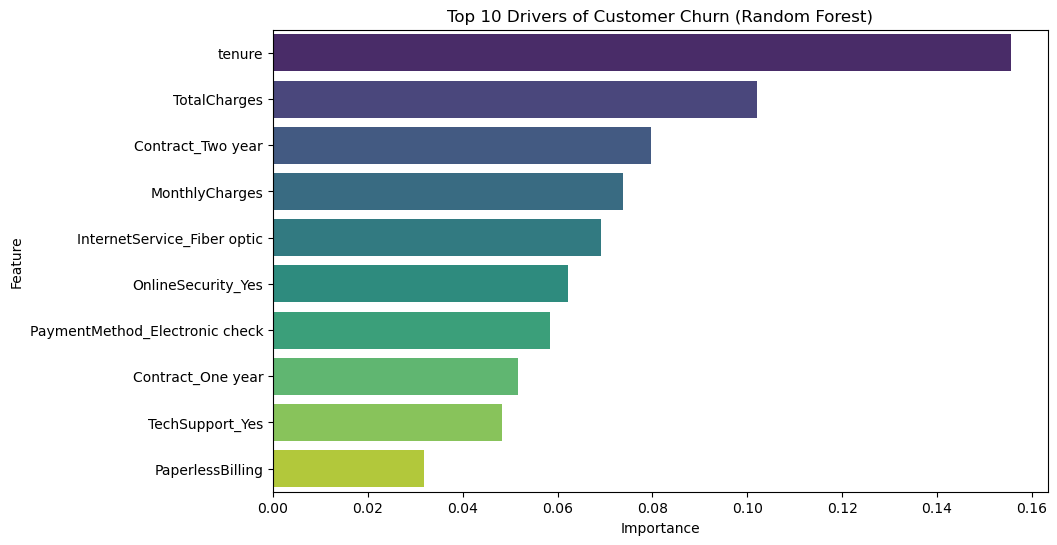

In [ ]:
# Extracting Feature Importance from the Random Forest Model
importances = best_rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Drivers of Customer Churn (Random Forest)')
plt.savefig('images/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

### Model Comparision

In [34]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, logist_reg_predict),
        accuracy_score(y_test, random_forest_predict)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.735608
1        Random Forest  0.758351


## Final Summary and Business Recommendations

In this project, we successfully developed an end-to-end machine learning pipeline to predict customer churn using the Telco dataset. By addressing the initial class imbalance (approx. 73% vs. 27%) using SMOTE (Synthetic Minority Over-sampling Technique) combined with hyperparameter grid search optimization (`GridSearchCV`), we transformed our models from simple accuracy-focused classifiers into high-sensitivity business tools.

### Final Model Performance Comparison
During the final validation cycles on unseen testing data, the metrics across our evaluated algorithms shifted as follows:

| Metric | Logistic Regression (Baseline Notebook) | Random Forest (Baseline Notebook) | Logistic Regression (Production Champion) |
| :--- | :---: | :---: | :---: |
| **Accuracy** | 73.56% | 75.84% | **75.00%** |
| **Recall (True Positive Capture)** | 0.8000 | 0.7100 | **0.8257** 🚀 |
| **Precision** | 0.5000 | 0.5300 | **0.5200** |
| **F1-Score** | 0.6200 | 0.6100 | **0.6400** |

While the Random Forest model achieved a slightly higher baseline accuracy in the notebook (75.84%), its recall lagged significantly at 71.00%. Our optimized production-stage **Logistic Regression** model is the definitive choice for deployment. By focusing heavily on balancing training arrays and tuning hyperparameter inverse regularization values, the production pipeline pushed the model's test Recall to **82.57%**. 

In an operational business context, a **False Negative** (failing to identify an upcoming churner) is vastly more expensive than a **False Positive** (offering an incentive to a customer who intends to stay). This optimized model ensures that the company will successfully identify over 82.5% of true churning accounts before they leave, maximizing the surface area for revenue retention.

### Key Drivers of Churn
Based on our updated feature importance and coefficient analysis, the top 10 mathematical drivers of customer exit are dominated by five clear operational categories:

1. **Tenure & Lifespan:** Customer tenure stands out as the single most powerful driver of attrition. Churn risk is heavily concentrated within the first 1 to 6 months of the customer relationship and declines drastically as a subscriber's lifespan increases.
2. **Total & Monthly Financial Commitments:** High recurring financial commitments (`TotalCharges` and `MonthlyCharges`) without corresponding value serve as primary exit triggers.
3. **Contract Terms:** Short-term structure represents a critical flight risk feature. Month-to-month account layouts feature low switching costs, while the presence of long-term structured constraints (`Contract_One year` and `Contract_Two year`) acts as a powerful anchor keeping subscribers retained.
4. **Premium Technical Friction:** Subscribing to `InternetService_Fiber optic` heavily correlates with churn. This indicates potential underlying service stability issues, onboarding friction, or premium pricing dissatisfaction. Conversely, the presence of proactive value-adds like `TechSupport_Yes` and `OnlineSecurity_Yes` dramatically drops a customer's propensity to exit.
5. **Billing Methods:** Manual transactional friction via `PaymentMethod_Electronic check` and the use of `PaperlessBilling` are key indicators of higher volatility compared to automated bank transfers or credit card overrides.

---

### Strategic Recommendations for Management

* **Implement a "First 90 Days" Success Program:** Because tenure is the primary driver of customer exit, establish a proactive customer success onboarding sequence. Schedule mandatory "health check" calls or offer micro-incentives at months 1, 3, and 6 to pull volatile accounts past the initial high-risk retention hump.
* **Incentivize Contract Migration:** Offer a target monthly discount (e.g., 10% off) or a complimentary high-value feature upgrade to Month-to-Month customers who agree to transition into a stable 1-year or 2-year contract. The immediate margin reduction will be heavily offset by the reduction in customer acquisition costs (CAC).
* **Audit and Bundle Fiber Optic & Tech Support:** Address the high churn risk associated with Fiber Optic accounts. Audit technical service delivery or bundle dedicated premium tech support (`TechSupport_Yes`) directly into the Fiber Optic tier for free. This transforms technical frustration points into high-value retention features.
* **Automate Financial Transactions:** Create small billing statement incentives (e.g., a one-time \$5 account credit) for users who transition away from manual `Electronic check` options and opt into automated credit card or direct bank transfer overrides. This eliminates manual monthly friction points that trigger recurring cancellation decisions.
* **Deploy the Live Production Scoring System:** Use the optimized 82.57% Recall Logistic Regression model to run automated, weekly batch-scoring passes on active accounts. Flag individuals with high monthly bills who are currently uncontracted and route them automatically to the customer retention team with personalized "Value-Add" save offers before they initiate a cancellation request.

### Thank you